<a href="https://colab.research.google.com/github/RhugvedChavan/Smart-Irrigation-Fault-Detection-Sytem/blob/main/Smart_Irrigation_Fault_Detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Irrigation Fault Detection using SVM Classifier

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Irrigation - Irrigation.csv")
print("Dataset Shape:", df.shape)

Dataset Shape: (40, 7)


In [ ]:
print(df.head())

   Soil_Moisture  Temperature  Humidity  Light_Intensity  Water_Flow_Rate  \
0             42           31        58              720               18   
1             45           30        61              680               17   
2             39           33        55              760               19   
3             48           29        64              650               16   
4             44           32        60              700               18   

   Pump_Pressure  Status  
0            2.4       0  
1            2.5       0  
2            2.3       0  
3            2.6       0  
4            2.4       0  


In [ ]:
X = df.drop("Status", axis=1)
y = df["Status"]
print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)


Features Shape: (40, 6)
Target Shape: (40,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)
print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (32, 6)
Testing Data: (8, 6)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_model.fit(X_train_scaled, y_train)

SVC()

In [ ]:
#Prediction
y_pred = svm_model.predict(X_test_scaled)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy Score:", accuracy)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy Score: 1.0

Confusion Matrix:
 [[4 0]
 [0 4]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



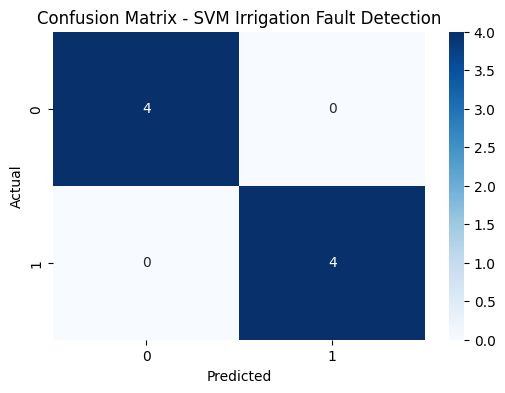

In [ ]:
#Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM Irrigation Fault Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Predict New Sensor Data
new_data = pd.DataFrame({
    "Soil_Moisture": [40],
    "Temperature": [32],
    "Humidity": [59],
    "Light_Intensity": [710],
    "Water_Flow_Rate": [18],
    "Pump_Pressure": [2.4]
})

# Scale the new data
new_data_scaled = scaler.transform(new_data)

# Make prediction
prediction = svm_model.predict(new_data_scaled)

# Display result
if prediction[0] == 0:
    print("\nPrediction: Normal Irrigation Condition")
else:
    print("\nPrediction: Faulty Irrigation Condition")


Prediction: Normal Irrigation Condition
